In [1]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
from dotenv import load_dotenv
import json
import os

from demo_db import get_db_url

load_dotenv()

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=create_engine(get_db_url())
)

ukrdc3 = ukrdc3_sessionmaker()


# Incident Intial Access 

Field IDs: QHD20 

This calculates the type of vascular access recorded in the UKRDC for the first dialysis session of incident patients. Incidence is defined as patients which start treatment without any dialysis or transplant treatments prior to the begining of the time window.




# Patient Demographic Statistics 

To return the statistics on the demographics data for at a given date we use the demographics calculator. This defaults to todays date and returns information for patients registered under any modality (in the future you will probably be able to specify a specific modality). 

These stats are being calculated in this demo for unit "RFBAK". Specifically it is a count of the total number of patients, dead or alive, who have ever appeared in a ukrdc feed from that particular unit, with a given property. 

The properties which get returned are:
- <strong> Ethnic group: </strong> the ethnic group from the patient table with the five ethnicity grouping used in the annual report.  
- <strong> Gender: </strong> the gender from the patient table interpreted as the person stated gender code in the NHS digital guidelines. 
- <strong> Age: </strong> The integer age in years (i.e taking account leap years and rounding down) calculated from the time of birth recorded in the patient table. 

The api returns the statistics as pydantic class which can be interogated. The output of the cell below demostrates how data returned looks for gender data. 

In [2]:
from ukrdc_stats.calculators.demographics import DemographicStatsCalculator
import datetime as dt
from IPython.display import display
import pprint
import json

calculator = DemographicStatsCalculator(ukrdc3, "RJZ")

output = calculator.extract_stats()

# format data for printing
formated_output = json.dumps(json.loads(output.gender.json()), indent=4)

print(formated_output)


{
    "metadata": {
        "title": "Gender Distribution",
        "summary": "",
        "description": "",
        "axis_titles": {
            "x": "Gender",
            "y": "No. of Patients"
        },
        "coding_standard_x": null,
        "units_y": null
    },
    "data": {
        "x": [
            "Female",
            "Male"
        ],
        "y": [
            2229,
            3444
        ],
        "error_y": null
    }
}


The ukrdc frontend uses plotly to visualise the data. Plotly is cross platform and can be used to make plots and dashboards in python. The following snippit of code will make a set of visualisations based on the output of the DemographicCalculator. 

The figures are currently being rendered in png mode so they persist when uploaded to github. This can be disabled when run locally to allow more interactivity.  

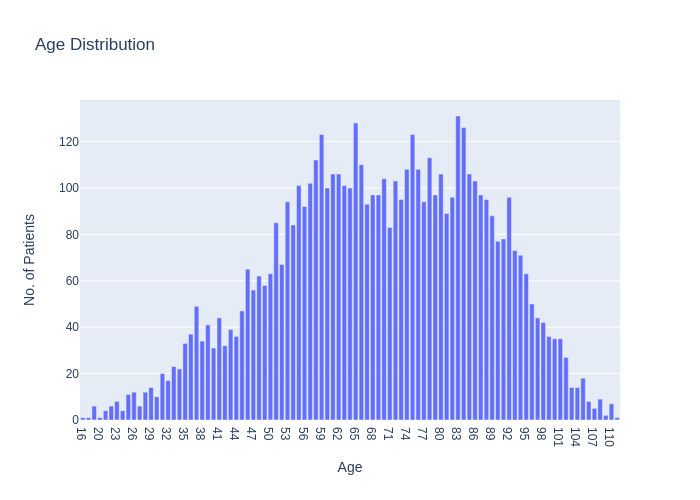

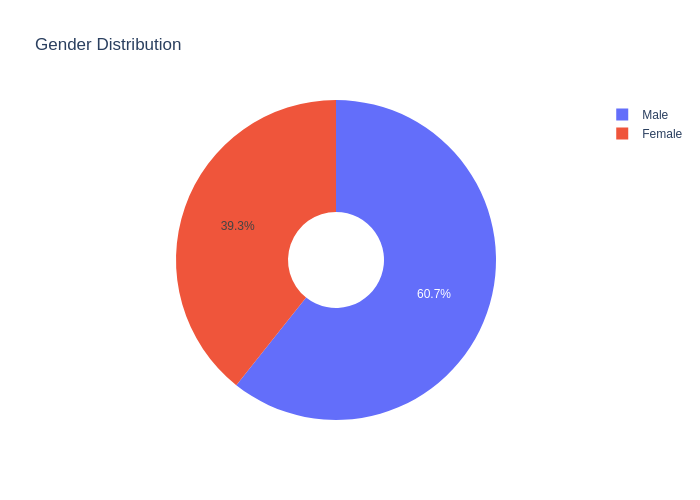

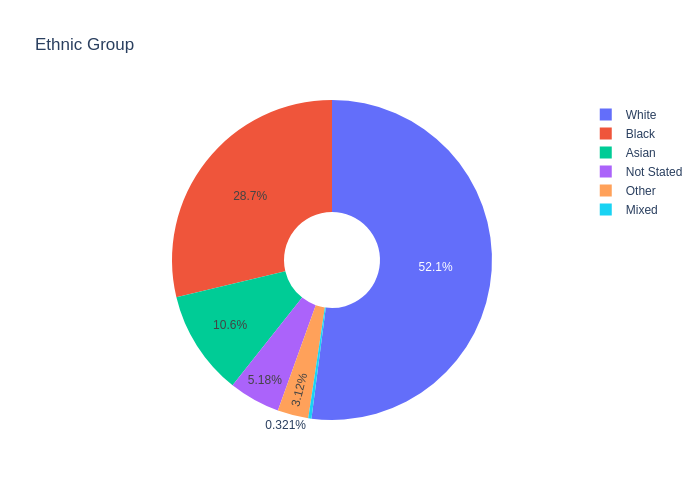

In [3]:
# visualise gender distribution with plotly
from cProfile import label
from importlib.metadata import metadata
import plotly.express as px

age_distribution = px.bar(
    x=output.age.data.x,
    y=output.age.data.y,
    title=output.age.metadata.title,
    labels={
        "x": output.age.metadata.axis_titles.x,
        "y": output.age.metadata.axis_titles.y,
    },
)
age_distribution.show("png")


gender_fig = px.pie(
    values=output.gender.data.y,
    names=output.gender.data.x,
    title=output.gender.metadata.title,
    hole=0.3,
)

gender_fig.show("png")

# plot bar charts of some other bits
ethnicity_fig = px.pie(
    values=output.ethnic_group.data.y,
    names=output.ethnic_group.data.x,
    title=output.ethnic_group.metadata.title,
    hole=0.3,
)
ethnicity_fig.show("png")
